In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import sys
sys.path.append('Tutorials')
import helpers
import importlib

In [11]:
# Force reload the helpers module to get the updated functions
importlib.reload(helpers)

<module 'helpers' from '/Users/mmathiou/Workspace/data16001/Tutorials/helpers.py'>

In this notebook, we experiment with one model that attempts to capture triadic closure.

## The model

The model takes as input the number $n$ of labeled nodes, and one parameter $p \in [0,1]$.
It proceeds in timesteps, $t = 0, 1, 2, \ldots$, every time considering all node pairs and possibly adding edges for some of them.
The generated graph instance is initialized with $V = \{1,2,\ldots,n\}$ and node edges $E = \emptyset$.

During timestep $t = 0$, edges are chosen at random similarly to the $G_{np}$ model: for every node pair $(u,v)$, the corresponding edge is added to $E$ with probability $p$.

For each timestep $ t = 1, 2, \ldots$, edges are added based on the common neighbors that appeared during the previous step.
Specifically, for a node pair $(u,v)$, let $n_{uv}^t$ be the number of common neighbors that $u$ and $v$ share at the beginning of the $t$-th timestep.
Then, each of the $$n_{uv}^t - n_{uv}^{t-1}$$ _newly_ common neighbors that were created during the previous step has a single chance to create an edge between $u$ and $v$ and add it to $E$. The probability of success is $p$, independently of other node pairs and edges.

If no newly common neighbors are created during a step, then the model returns the latest graph instance.

<img src="./triadic-closure-legend.jpg" alt="Model description" width="1000">

The process is implemented in the `generate_graph` function below.


In [12]:
def generate_graph(nn, prob_function, **parameters):
    """
    Generates a graph according to our model.
    
    Parameters:
    nn (int): The number of nodes in the graph.
    prob_function (function): A function that calculates the probability of adding an edge based on the neighborhood overlap.
    **parameters: Additional parameters to be passed to the probability function.
    
    Returns:
    networkx.Graph: The generated graph.
    The function iteratively adding edges to the graph based on the newly common neighbors of every iteration.
    """
    
    GG = nx.Graph() # Holds the current state of the graph
    GG.add_nodes_from(range(nn))
    HH = nx.Graph() # Holds the previous state of the graph
    HH.add_nodes_from(GG.nodes())

    for step in range(0, nn*(nn-1)//2):
        edges_to_add = []
        UU = list(GG.nodes())
        # go over all pairs of nodes
        for i, u in enumerate(UU):
            for v in UU[i+1:]:
                if not GG.has_edge(u, v):
                    # there is one chance to add the edge at t=0
                    if step == 0:
                        new_overlap = 0
                        old_overlap = -1
                    # otherwise, we need to calculate the neighborhood overlap (i.e., the common neighbors)
                    else:
                        new_overlap = len(set(GG.neighbors(u)) & set(GG.neighbors(v)))
                        old_overlap = len(set(HH.neighbors(u)) & set(HH.neighbors(v)))

                    # if the overlap increased, we calculate the probability of adding the edge
                    if new_overlap > old_overlap:
                        p_add = helpers.prob_to_add_now(new_overlap, old_overlap, prob_function, **parameters)
                        # throw a coin to decide whether to add the edge
                        coin = np.random.rand()
                        if coin <= p_add:
                            edges_to_add.append((u, v))
                            # print(">>>", new_overlap, old_overlap, p_add, coin, 1)
                        else:
                            # print(">>>", new_overlap, old_overlap, p_add, coin, 0)
                            pass

        # if no edges were added, we stop
        if len(edges_to_add) == 0:
            break
        # keep track of the previous graph
        HH = GG.copy()
        # add the new edges
        GG.add_edges_from(edges_to_add)

    return GG

## Single instance

Let's explore one instance generated by our model.

In [13]:
nn = 100
pp = 0.05

GG = generate_graph(nn, prob_function = helpers._prob_independent, pp = pp)

print(f"Generated graph with {GG.number_of_nodes()} nodes and {GG.number_of_edges()} edges.")

Generated graph with 100 nodes and 326 edges.


Let's visualize the graph we generated, along with some statistics.

Final number of edges: 326 Density: 0.07 Average clustering coefficient: 0.18
Final number of connected components: 3


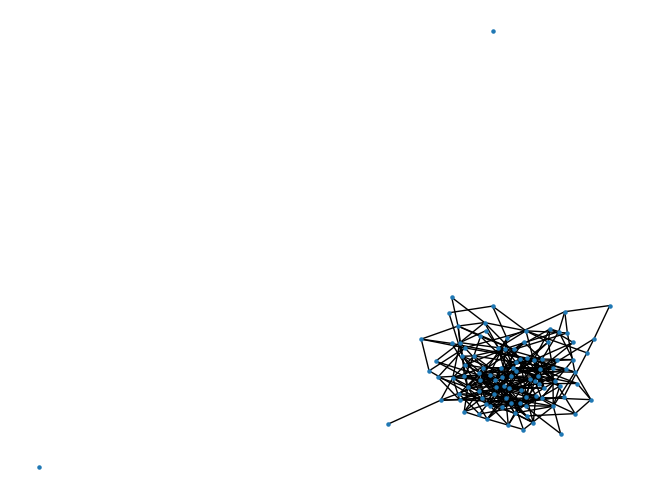

In [14]:
# Post-generation analysis
print(f"Final number of edges: {GG.number_of_edges()}", 
            f"Density: {nx.density(GG):.2f}",
            f"Average clustering coefficient: {nx.average_clustering(GG):.2f}")
print(f"Final number of connected components: {nx.number_connected_components(GG)}")
# Draw the graph
nx.draw(GG, node_size=5, pos=nx.layout.spring_layout(GG))


## Simulation and empirical distributions

We will now generate multiple graphs for fixed $n$ and varying values of $p$, so that we observe how $p$ affects attributs of the generated graph.

In [15]:
# Gather the simulation results in a dataframe
results = pd.DataFrame({"p": [], "n": [], "m": [], "density": [], "cc": []})

# Start the simulation
density_gap = 1.01
pp_right = 1.0
pp_left = 1 / nn
pp_trials = [2.0**(-i) for i in np.linspace(-np.log2(pp_right), -np.log2(pp_left), 10)]

# Repeat the simulation until the largest gap in average density by pp is less than a threshold
# Note: Increase the threshold to get faster results
while density_gap > 0.25:
    for pp in pp_trials:
        print(f"p={pp:.4f}")
        for _ in range(5): # Repeat the simulation a few times for each pp
            GG = generate_graph(nn, prob_function=helpers._prob_independent, pp = pp)
            entry = pd.DataFrame({"p": [pp], 
                "n": [GG.number_of_nodes()], "m": [GG.number_of_edges()], 
                "density": [nx.density(GG)],
                "cc": [nx.average_clustering(GG)]})
            results = pd.concat([results, entry], ignore_index=True)
    density_gap, pp_left, pp_right = helpers.find_largest_gap(results)
    pp_trials = pp_left + (pp_right - pp_left) * np.linspace(0.0, 1.0, 3)


p=1.0000
p=0.5995
p=0.3594
p=0.2154
p=0.1292
p=0.0774
p=0.0464
p=0.0278
p=0.0167
p=0.0100
The largest gap in density is 0.92 between p=0.0464158883 and p=0.0774263683
p=0.0464
p=0.0619
p=0.0774
The largest gap in density is 0.93 between p=0.0464158883 and p=0.0774263683
p=0.0464
p=0.0619
p=0.0774
The largest gap in density is 0.87 between p=0.0464158883 and p=0.0619211283
p=0.0464
p=0.0542
p=0.0619
The largest gap in density is 0.88 between p=0.0464158883 and p=0.0541685083
p=0.0464
p=0.0503
p=0.0542
The largest gap in density is 0.45 between p=0.0502921983 and p=0.0541685083
p=0.0503
p=0.0522
p=0.0542
The largest gap in density is 0.35 between p=0.0502921983 and p=0.0522303533
p=0.0503
p=0.0513
p=0.0522
The largest gap in density is 0.28 between p=0.0464158883 and p=0.0502921983
p=0.0464
p=0.0484
p=0.0503
The largest gap in density is 0.27 between p=0.0512612758 and p=0.0522303533
p=0.0513
p=0.0517
p=0.0522
The largest gap in density is 0.25 between p=0.0464158883 and p=0.0502921983


Let's plot the results from the sampled graphs.

The first two plots will show how the density and average clustering coefficient (y-axis) vary against different values of parameter `p` (x-axis).

The third plot will show how the average clustering coefficient (y-axis) varies against density (x-axis).

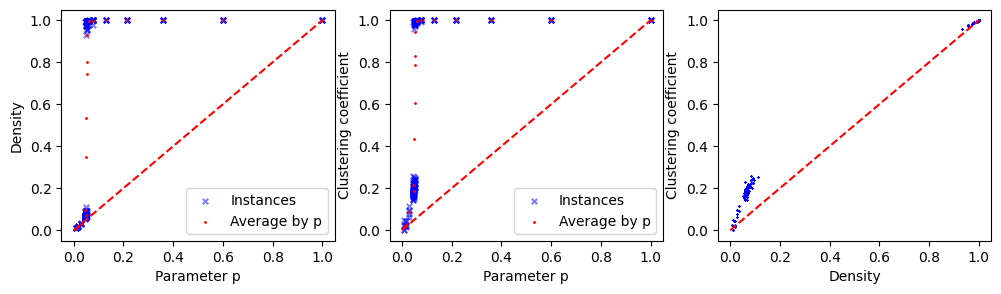

In [16]:
density = results["density"]
cc = results["cc"]
pp_values = results["p"]

grouped = results.groupby("p")
mean_density = grouped["density"].mean()
mean_cc = grouped["cc"].mean()

fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].plot([0, 1], [0, 1], 'r--')
ax[0].set_xlabel("Parameter p")
ax[0].set_ylabel("Density")
ax[0].scatter(pp_values, density, marker = 'x', s=15, alpha = 0.5, c = "blue", label="Instances")
ax[0].scatter(mean_density.index, mean_density.values, marker = 'o', s=1, c = "red", label="Average by p")
ax[0].legend()


ax[1].plot([0, 1], [0, 1], 'r--')
ax[1].set_xlabel("Parameter p")
ax[1].set_ylabel("Clustering coefficient")
ax[1].scatter(pp_values, cc, marker='x', s=15, alpha = 0.5, c = "blue", label="Instances")
ax[1].scatter(mean_cc.index, mean_cc.values, marker = 'o', s=1, c = "red", label="Average by p")
ax[1].legend()   

ax[2].plot([0, 1], [0, 1], 'r--')
ax[2].set_xlabel("Density")
ax[2].set_ylabel("Clustering coefficient")
ax[2].scatter(density, cc, marker = 'x', s=1, c = "blue", label="Instances")



In all plots, the blue markers show the values for specific graph instances.

In the first two plots, we observe very sharp threshold behavior: as `p` increases, the density and clustering coefficient ''jump'' around a specific value of `p` from low values (near `p`) to almost or exactly $1$.

Notice also the averages by `p`, indicated with the red markers, and notice that some of those averages appear between the extremes (i.e., the low and high density and clustering coefficient values). These correspond to those values of `p` for which the model sometimes gives a sparse graph (density near `p`) and sometimes a full graph.

In the third plot, we see that the  clustering coefficient of the graphs is higher than the density, which corresponds to the triadic closure property we intended to capture.

